<a href="https://colab.research.google.com/github/smonodeep/DynamicValuationGovernance/blob/main/1_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('/content/final_model_dataset.csv')
display(df.head())

,city,quarter,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,repo_lag
0,bangalore,Q1 2015,104.4500,61.806841,0.043538,0.237475,-0.193937,7.782887,NaN,NaN,NaN,NaN
1,bangalore,Q1 2016,114.6000,71.406332,0.092739,0.144372,-0.051633,7.657853,0.237475,0.043538,-0.016196,NaN
2,bangalore,Q1 2017,121.9875,75.582470,0.062471,0.056838,0.005633,6.962920,0.144372,0.092739,-0.095133,-0.016196
3,bangalore,Q1 2018,145.2250,77.997789,0.174366,0.031456,0.142910,7.466353,0.056838,0.062471,0.069808,-0.095133
4,bangalore,Q1 2019,144.7375,83.885498,-0.003363,0.072772,-0.076135,7.397403,0.031456,0.174366,-0.009278,0.069808


In [ ]:
df.columns.to_list()

['city',
 'quarter',
 'rent',
 'hpi',
 'rent_growth',
 'hpi_growth',
 'valuation_gap',
 'repo_rate',
 'hpi_lag',
 'rent_lag',
 'repo_growth',
 'repo_lag']

In [ ]:
df.columns.to_list()

['city',
 'quarter',
 'rent',
 'hpi',
 'rent_growth',
 'hpi_growth',
 'valuation_gap',
 'repo_rate',
 'hpi_lag',
 'rent_lag',
 'repo_growth',
 'repo_lag']

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/final_model_dataset.csv')
display(df.head())

,city,quarter,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,repo_lag
0,bangalore,Q1 2015,104.4500,61.806841,0.043538,0.237475,-0.193937,7.782887,NaN,NaN,NaN,NaN
1,bangalore,Q1 2016,114.6000,71.406332,0.092739,0.144372,-0.051633,7.657853,0.237475,0.043538,-0.016196,NaN
2,bangalore,Q1 2017,121.9875,75.582470,0.062471,0.056838,0.005633,6.962920,0.144372,0.092739,-0.095133,-0.016196
3,bangalore,Q1 2018,145.2250,77.997789,0.174366,0.031456,0.142910,7.466353,0.056838,0.062471,0.069808,-0.095133
4,bangalore,Q1 2019,144.7375,83.885498,-0.003363,0.072772,-0.076135,7.397403,0.031456,0.174366,-0.009278,0.069808


In [ ]:
display(df.describe())

,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,repo_lag
count,175.000000,175.000000,175.000000,175.000000,175.000000,167.000000,171.000000,171.000000,161.000000,157.000000
mean,130.633449,93.294346,0.033041,0.053317,-0.020276,7.064108,0.008345,0.006289,-0.017218,-0.009859
std,24.404011,17.149197,0.073448,0.089757,0.103587,0.570082,0.197581,0.134513,0.096505,0.104470
min,94.500000,59.203005,-0.273759,-0.300430,-0.478007,5.910980,-0.980377,-0.666421,-0.165880,-0.165880
25%,110.600000,78.777559,-0.002539,0.000469,-0.078284,6.676732,-0.007579,-0.016117,-0.088565,-0.094899
50%,124.300000,95.690968,0.038898,0.061195,-0.024529,7.119050,0.050597,0.034501,-0.034087,-0.033334
75%,144.256250,103.979883,0.074434,0.105878,0.046676,7.405995,0.103158,0.069209,0.072876,0.074205
max,203.675000,146.223219,0.277253,0.275671,0.230875,8.791340,0.259346,0.277253,0.263040,0.263040


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a sortable quarter column for chronological plotting
df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

### Average Rent and HPI by City

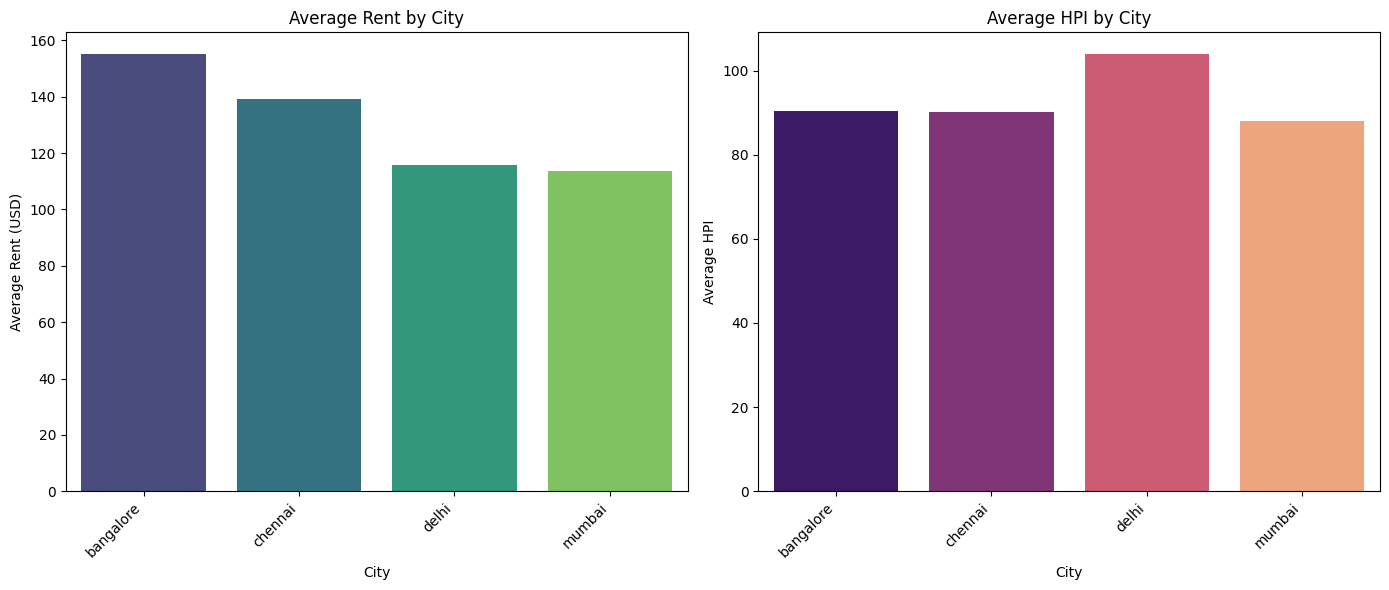

In [ ]:
# Calculate average rent and HPI by city
avg_by_city = df.groupby('city')[['rent', 'hpi']].mean().reset_index()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='city', y='rent', hue='city', data=avg_by_city, palette='viridis', legend=False)
plt.title('Average Rent by City')
plt.ylabel('Average Rent (USD)')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x='city', y='hpi', hue='city', data=avg_by_city, palette='magma', legend=False)
plt.title('Average HPI by City')
plt.ylabel('Average HPI')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Rent and HPI Trends Over Quarters per City

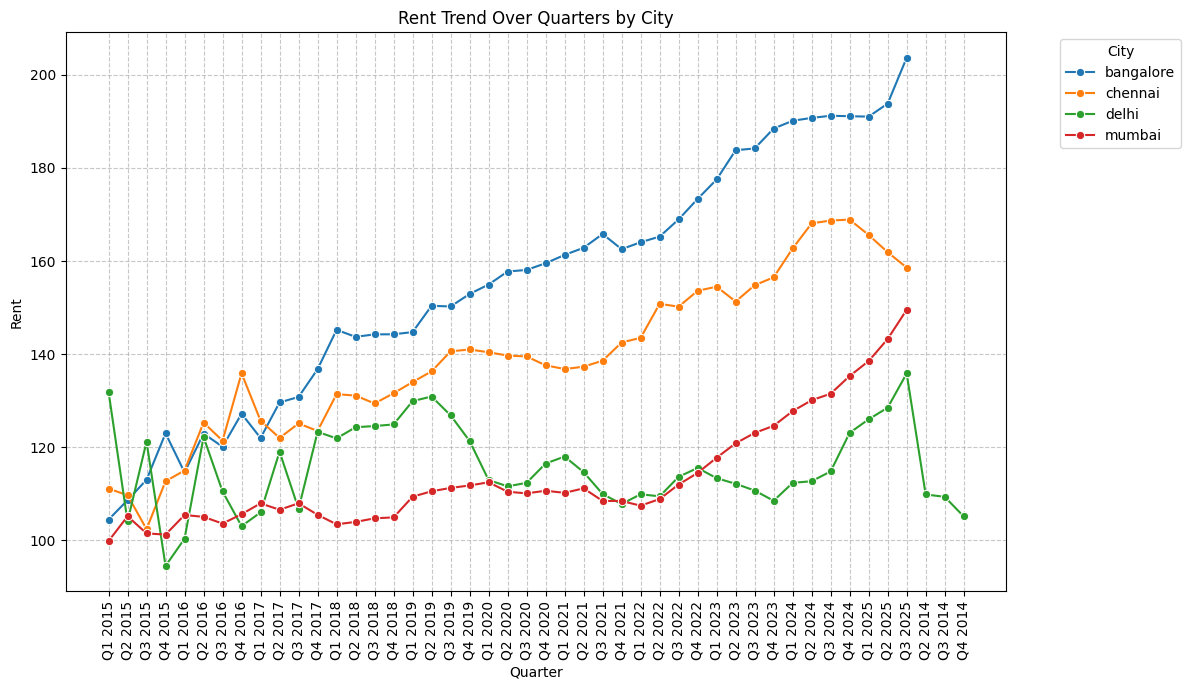

In [ ]:
# Line plot for Rent trends by Quarter and City
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='rent', hue='city', data=df, marker='o')
plt.title('Rent Trend Over Quarters by City')
plt.ylabel('Rent')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Plot Rent Growth

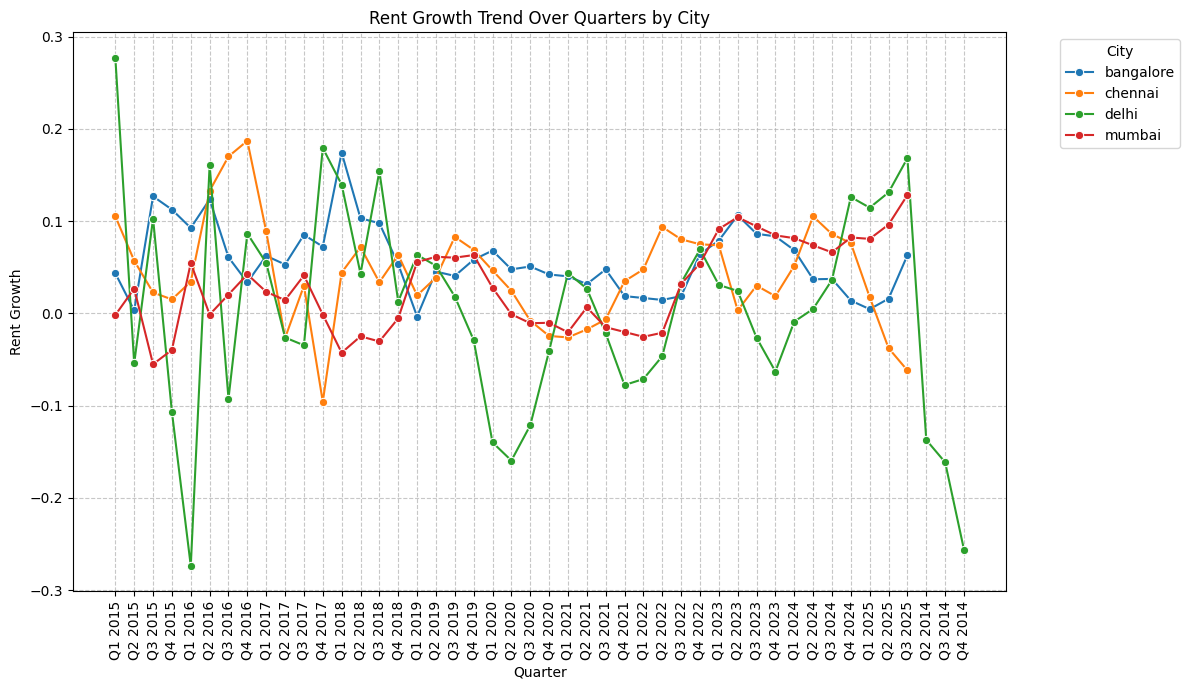

In [ ]:
# Line plot for Rent trends by Quarter and City
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='rent_growth', hue='city', data=df, marker='o')
plt.title('Rent Growth Trend Over Quarters by City')
plt.ylabel('Rent Growth')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Plot Moving Average for Rent Growth to Extract Signal

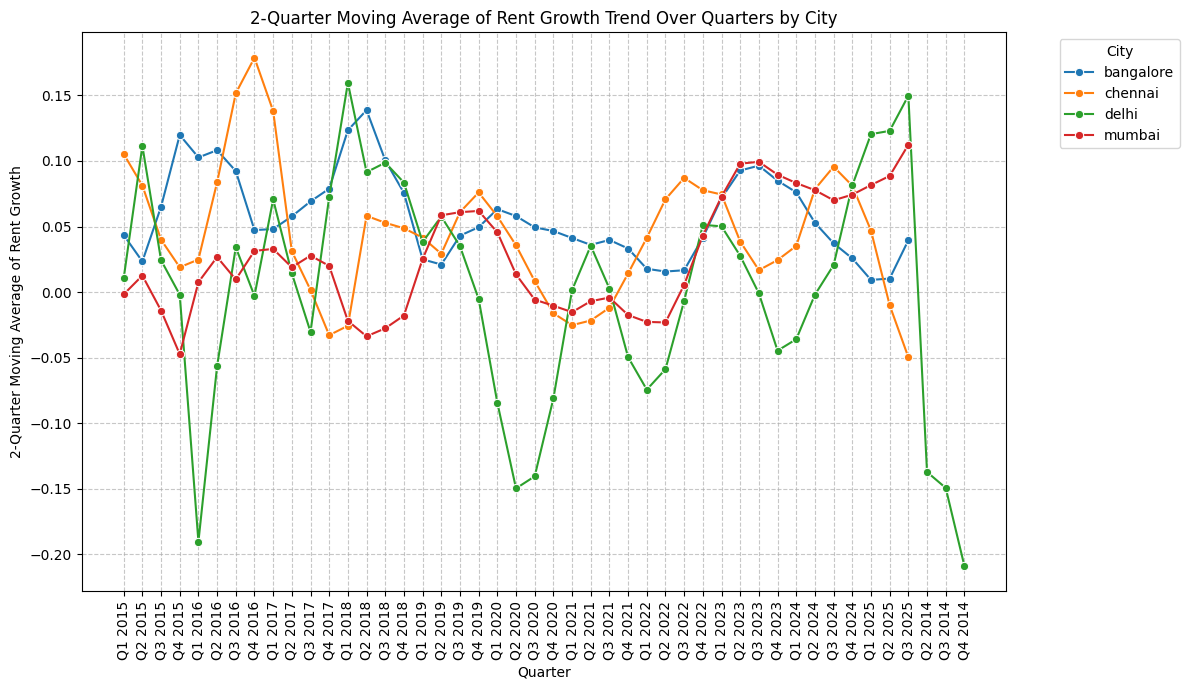

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and 'year_quarter' is created for sorting
# This assumes the file is in the same location as previous operations
df = pd.read_csv('/content/final_model_dataset.csv')

# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 2-quarter moving average for rent_growth, grouped by city
df['rent_growth_ma2'] = df.groupby('city')['rent_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

# Plot the 2-quarter moving average of rent growth quarter-wise
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='rent_growth_ma2', hue='city', data=df, marker='o')
plt.title('2-Quarter Moving Average of Rent Growth Trend Over Quarters by City')
plt.ylabel('2-Quarter Moving Average of Rent Growth')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

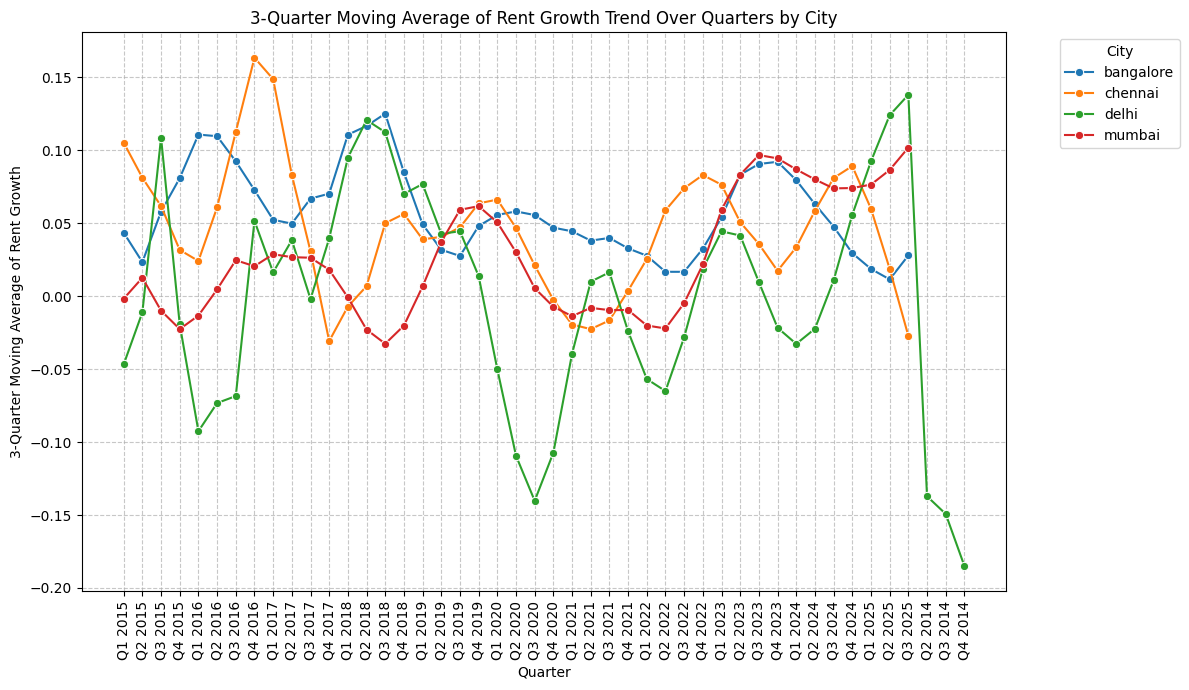

In [ ]:
# Ensure 'year_quarter' and 'regime' are defined if not already
# (Assuming these transformations might be needed for other parts of df within this cell's context
#  or for future use, as the original notebook defines them earlier)
# If these are not used within this specific plot, they can be omitted.
# However, to be safe and ensure df is fully prepared as intended by earlier cells:
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
    df = df.sort_values(by=['city', 'year_quarter'])

# Calculate rent_growth if it doesn't exist (assuming this might be a derived column needed for MA)
# This is a placeholder; usually, you'd ensure previous cells run or add all dependencies.
# For this specific error (df not defined), just defining df is the direct fix.
# The earlier notebook state implies 'rent_growth' and 'valuation_gap' already exist in df.

df['rent_growth_ma3'] = df.groupby('city')['rent_growth'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='rent_growth_ma3', hue='city', data=df, marker='o')
plt.title('3-Quarter Moving Average of Rent Growth Trend Over Quarters by City')
plt.ylabel('3-Quarter Moving Average of Rent Growth')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

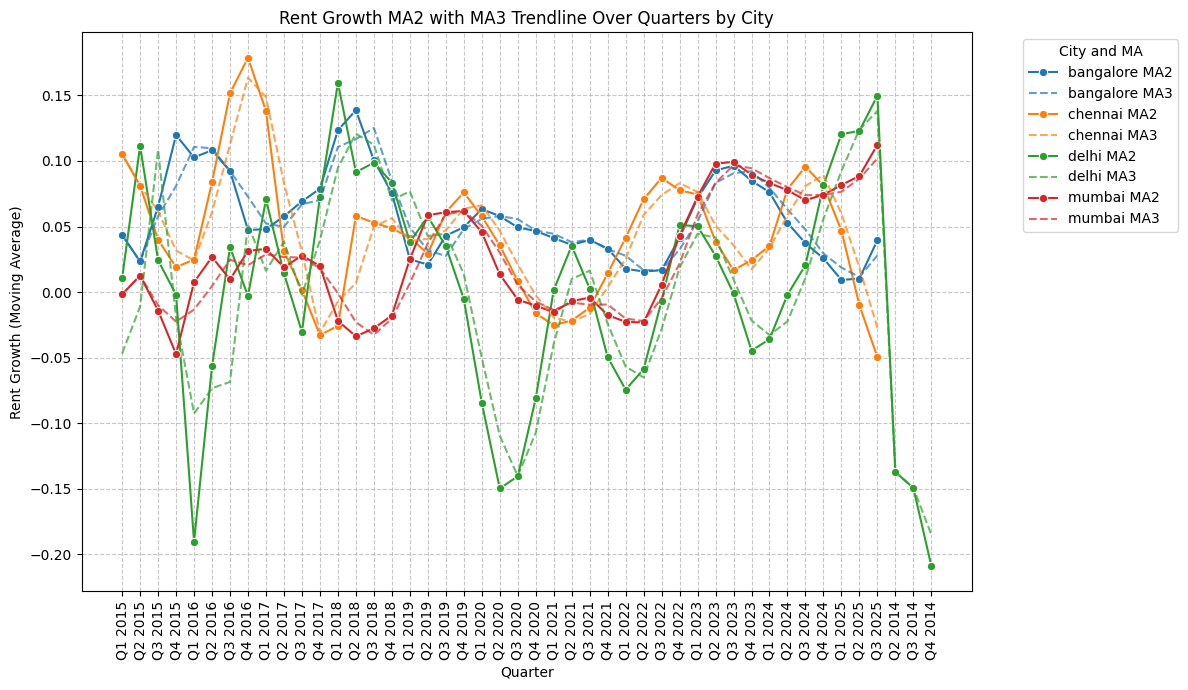

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 2-quarter moving average for rent_growth, grouped by city
df['rent_growth_ma2'] = df.groupby('city')['rent_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

# Calculate the 3-quarter moving average for rent_growth, grouped by city (for trendline)
df['rent_growth_ma3'] = df.groupby('city')['rent_growth'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Plot the 2-quarter moving average of Rent Growth
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='rent_growth_ma2', hue='city', data=df, marker='o')

# Add the 3-quarter moving average as a trendline
sns.lineplot(x='quarter', y='rent_growth_ma3', hue='city', data=df, linestyle='--', alpha=0.7)

plt.title('Rent Growth MA2 with MA3 Trendline Over Quarters by City')
plt.ylabel('Rent Growth (Moving Average)')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)

# Create a single legend that combines both MA2 and MA3 for each city
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = []
new_handles = []

# Assuming cities are repeated in order for MA2 and MA3, group them
num_cities = len(df['city'].unique())
for i in range(num_cities):
    city = df['city'].unique()[i]
    # The first 'num_cities' handles are for MA2, the next 'num_cities' are for MA3
    new_handles.append(handles[i]) # MA2 handle for city
    new_labels.append(f'{city} MA2')
    new_handles.append(handles[i + num_cities]) # MA3 handle for city
    new_labels.append(f'{city} MA3')

# Customize legend to show both MA2 and MA3 for each city
plt.legend(handles=new_handles, labels=new_labels, title='City and MA', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

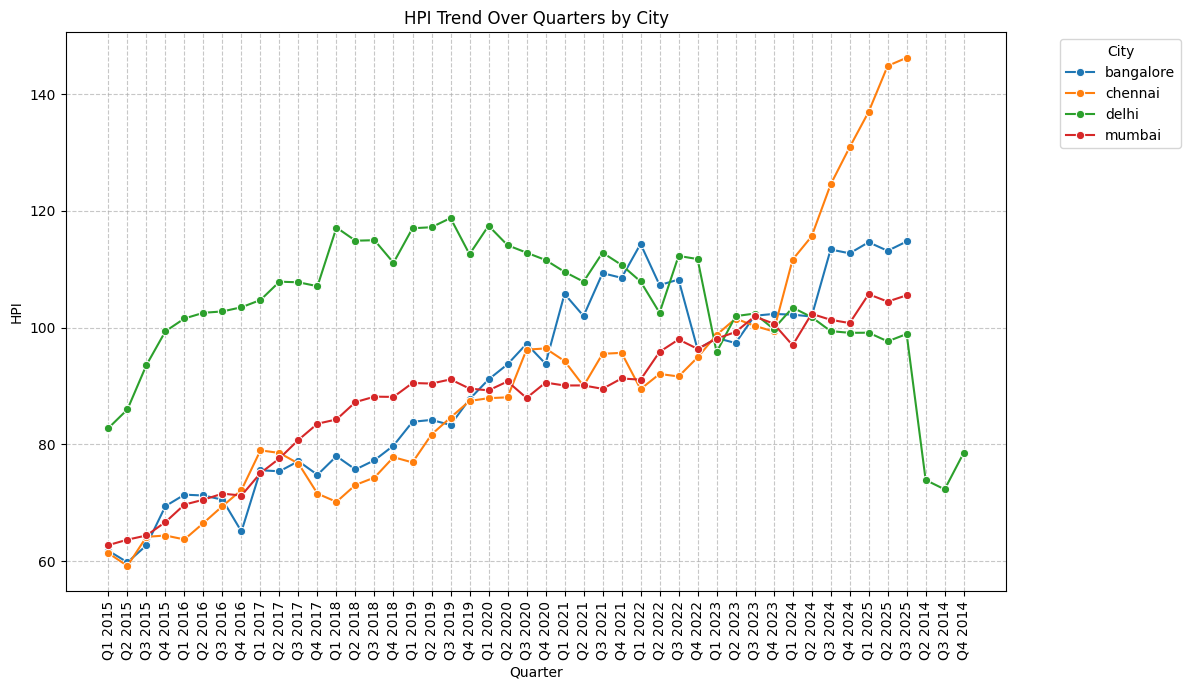

In [ ]:
# Line plot for HPI trends by Quarter and City
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='hpi', hue='city', data=df, marker='o')
plt.title('HPI Trend Over Quarters by City')
plt.ylabel('HPI')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

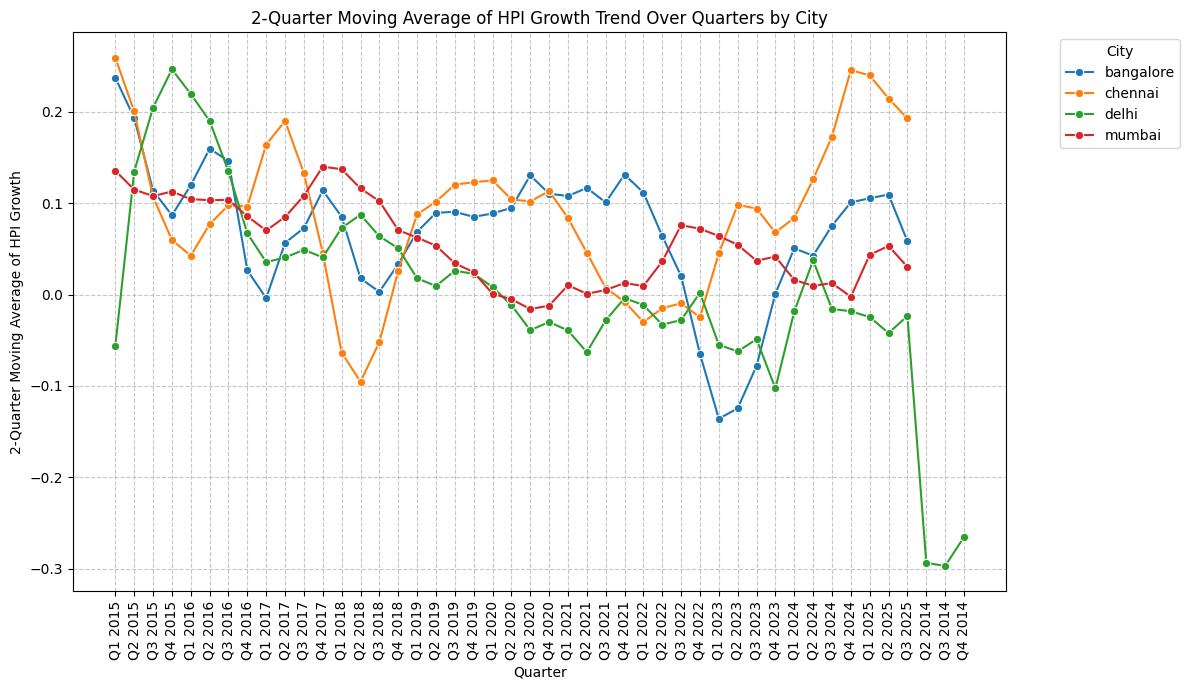

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and 'year_quarter' is created for sorting
# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 2-quarter moving average for hpi_growth, grouped by city
df['hpi_growth_ma2'] = df.groupby('city')['hpi_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

# Plot the 2-quarter moving average of hpi growth quarter-wise
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='hpi_growth_ma2', hue='city', data=df, marker='o')
plt.title('2-Quarter Moving Average of HPI Growth Trend Over Quarters by City')
plt.ylabel('2-Quarter Moving Average of HPI Growth')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

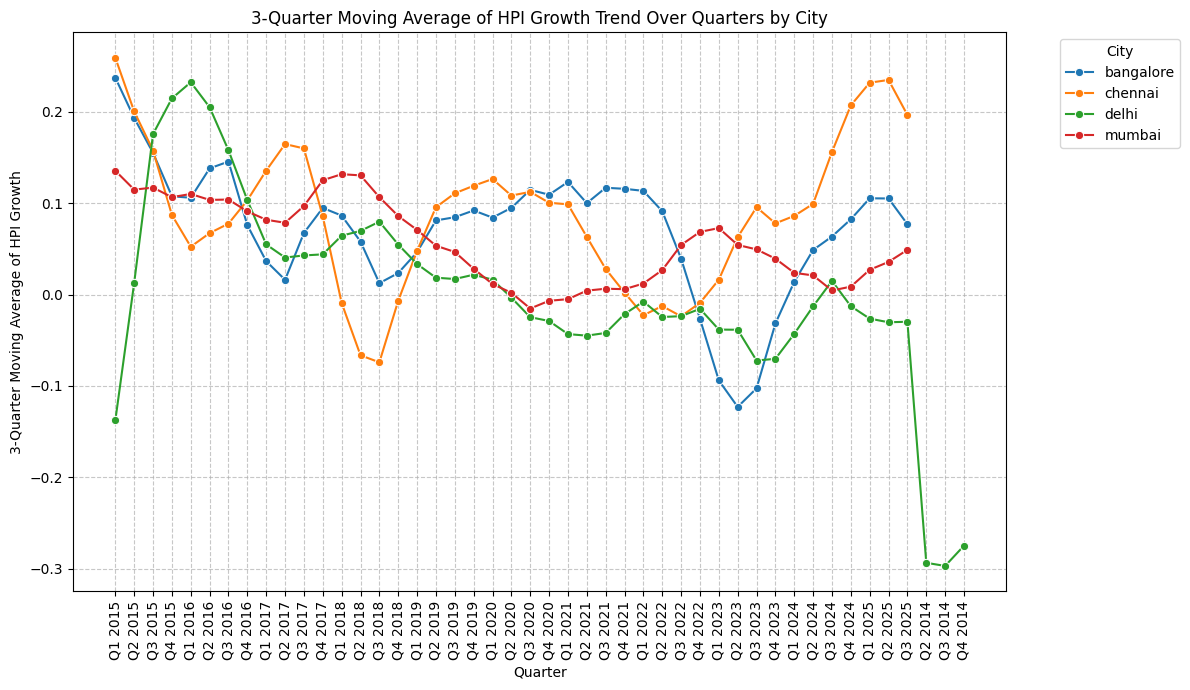

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 3-quarter moving average for hpi_growth, grouped by city
df['hpi_growth_ma3'] = df.groupby('city')['hpi_growth'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Plot the 3-quarter moving average of hpi growth quarter-wise
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='hpi_growth_ma3', hue='city', data=df, marker='o')
plt.title('3-Quarter Moving Average of HPI Growth Trend Over Quarters by City')
plt.ylabel('3-Quarter Moving Average of HPI Growth')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

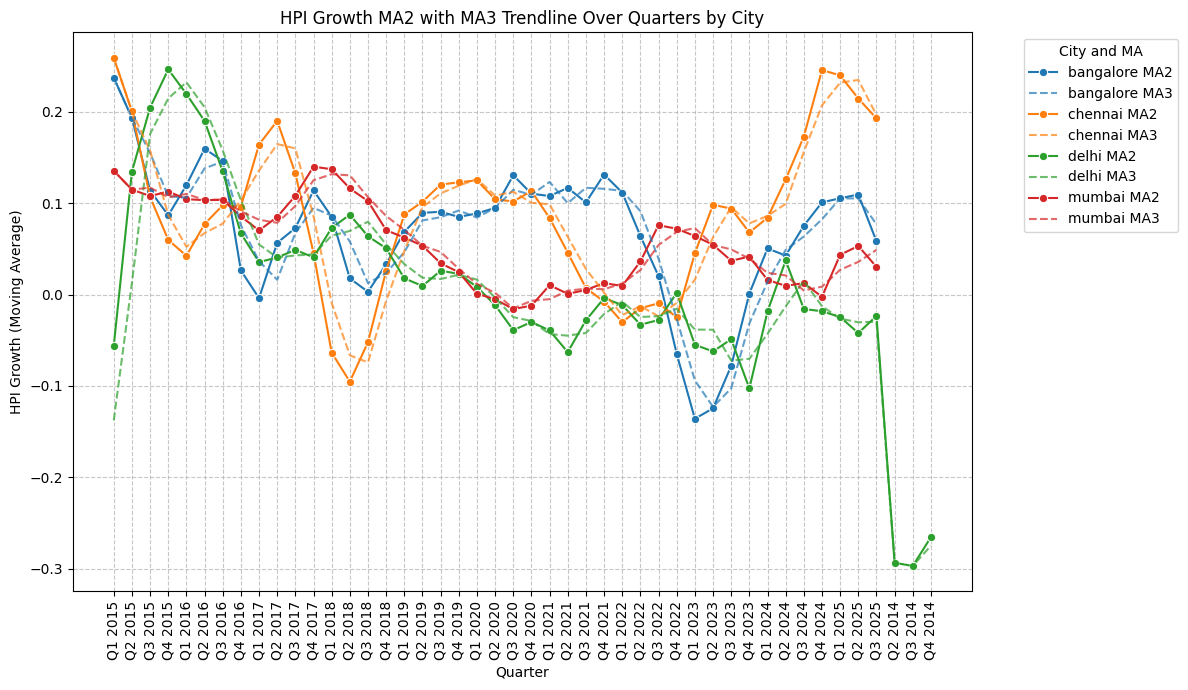

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 2-quarter moving average for hpi_growth, grouped by city
df['hpi_growth_ma2'] = df.groupby('city')['hpi_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

# Calculate the 3-quarter moving average for hpi_growth, grouped by city (for trendline)
df['hpi_growth_ma3'] = df.groupby('city')['hpi_growth'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Plot the 2-quarter moving average of HPI growth
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='hpi_growth_ma2', hue='city', data=df, marker='o')

# Add the 3-quarter moving average as a trendline
sns.lineplot(x='quarter', y='hpi_growth_ma3', hue='city', data=df, linestyle='--', alpha=0.7) # Removed legend=False

plt.title('HPI Growth MA2 with MA3 Trendline Over Quarters by City')
plt.ylabel('HPI Growth (Moving Average)')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)

# Create a single legend that combines both MA2 and MA3 for each city
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = []
new_handles = []

# Assuming cities are repeated in order for MA2 and MA3, group them
num_cities = len(df['city'].unique())
for i in range(num_cities):
    city = df['city'].unique()[i]
    # The first 'num_cities' handles are for MA2, the next 'num_cities' are for MA3
    new_handles.append(handles[i]) # MA2 handle for city
    new_labels.append(f'{city} MA2')
    new_handles.append(handles[i + num_cities]) # MA3 handle for city
    new_labels.append(f'{city} MA3')

# Customize legend to show both MA2 and MA3 for each city
plt.legend(handles=new_handles, labels=new_labels, title='City and MA', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Plot

### Repo Growth Trend Over Quarters

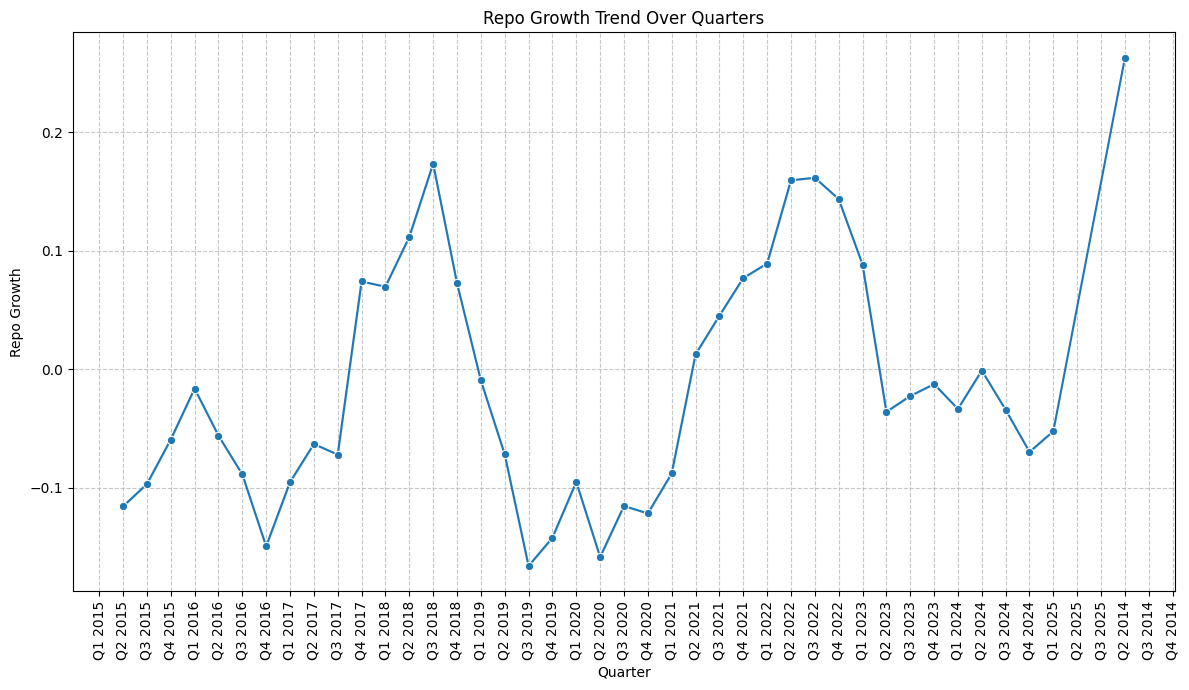

In [ ]:
# Line plot for Repo Growth trends by Quarter
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='repo_growth', data=df, marker='o')
plt.title('Repo Growth Trend Over Quarters')
plt.ylabel('Repo Growth')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Repo Lag Trend Over Quarters

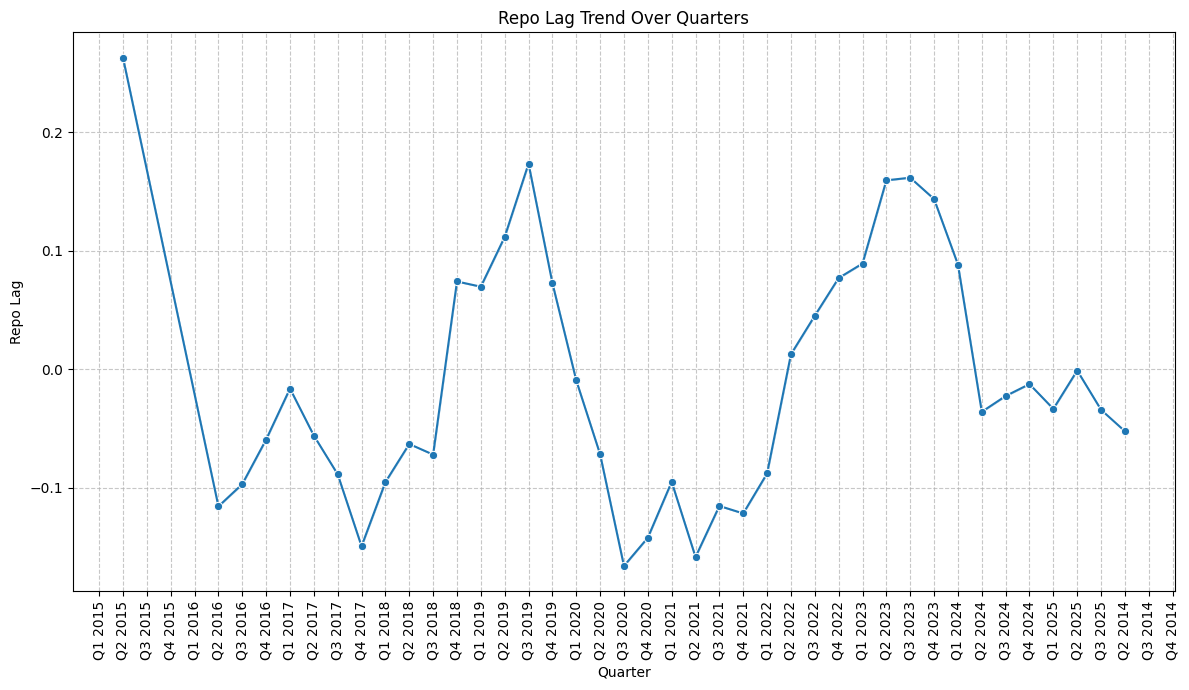

In [ ]:
# Line plot for Repo Lag trends by Quarter
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='repo_lag', data=df, marker='o')
plt.title('Repo Lag Trend Over Quarters')
plt.ylabel('Repo Lag')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Moving Average of Repo Growth

In [ ]:
df['repo_growth_ma2'] = df.groupby('city')['repo_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
display(df[['city', 'quarter', 'repo_growth', 'repo_growth_ma2']].head())

,city,quarter,repo_growth,repo_growth_ma2
0,bangalore,Q1 2015,NaN,NaN
11,bangalore,Q2 2015,-0.115619,-0.115619
22,bangalore,Q3 2015,-0.096838,-0.106228
33,bangalore,Q4 2015,-0.059205,-0.078021
1,bangalore,Q1 2016,-0.016196,-0.037700


First, we will calculate `hpi_lag` as the previous quarter's HPI, grouped by city, and then create the `regime` variable using `pd.qcut`.

In [ ]:
df['hpi_lag'] = df.groupby('city')['hpi'].shift(1)
df['regime'] = pd.qcut(df['hpi_lag'], q=3, labels=['low', 'mid', 'high'], duplicates='drop')
display(df[['city', 'quarter', 'hpi', 'hpi_lag', 'regime']].head())

,city,quarter,hpi,hpi_lag,regime
0,bangalore,Q1 2015,61.806841,NaN,NaN
11,bangalore,Q2 2015,59.819703,61.806841,low
22,bangalore,Q3 2015,62.725676,59.819703,low
33,bangalore,Q4 2015,69.447592,62.725676,low
1,bangalore,Q1 2016,71.406332,69.447592,low


To proceed with plotting, please provide the definition or formula for 'Valuation Gap'. Once I have that, I can generate the requested plot.

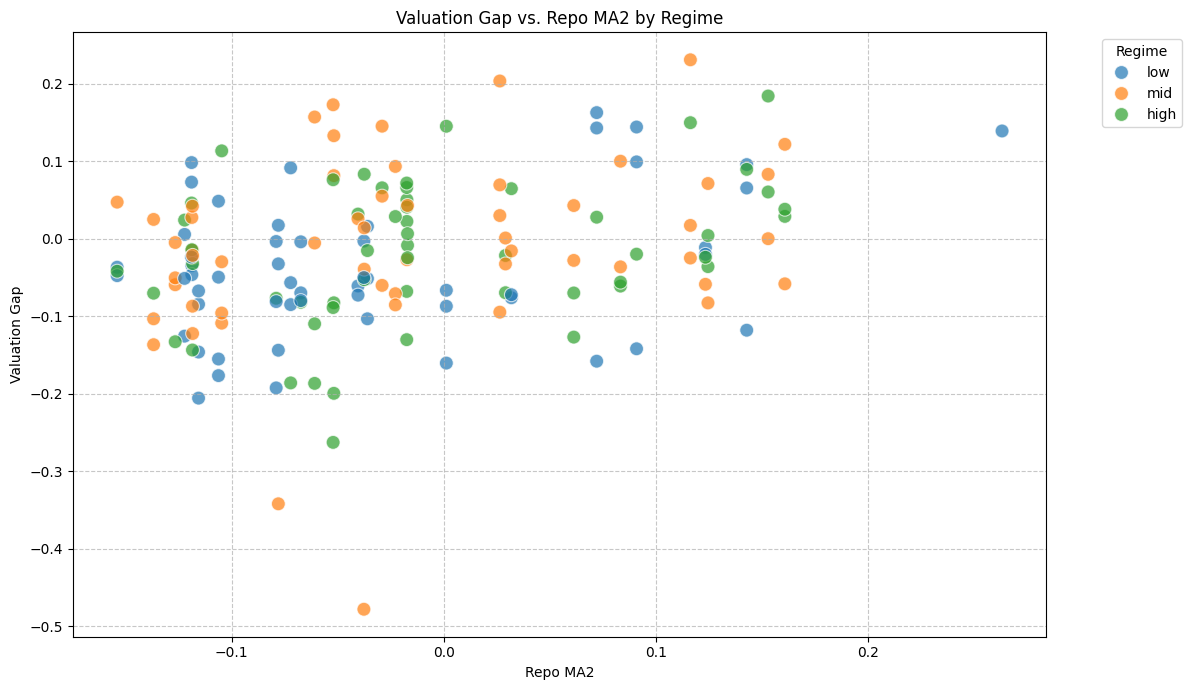

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='repo_growth_ma2', y='valuation_gap', hue='regime', data=df, s=100, alpha=0.7)
plt.title('Valuation Gap vs. Repo MA2 by Regime')
plt.xlabel('Repo MA2')
plt.ylabel('Valuation Gap')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Regime', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

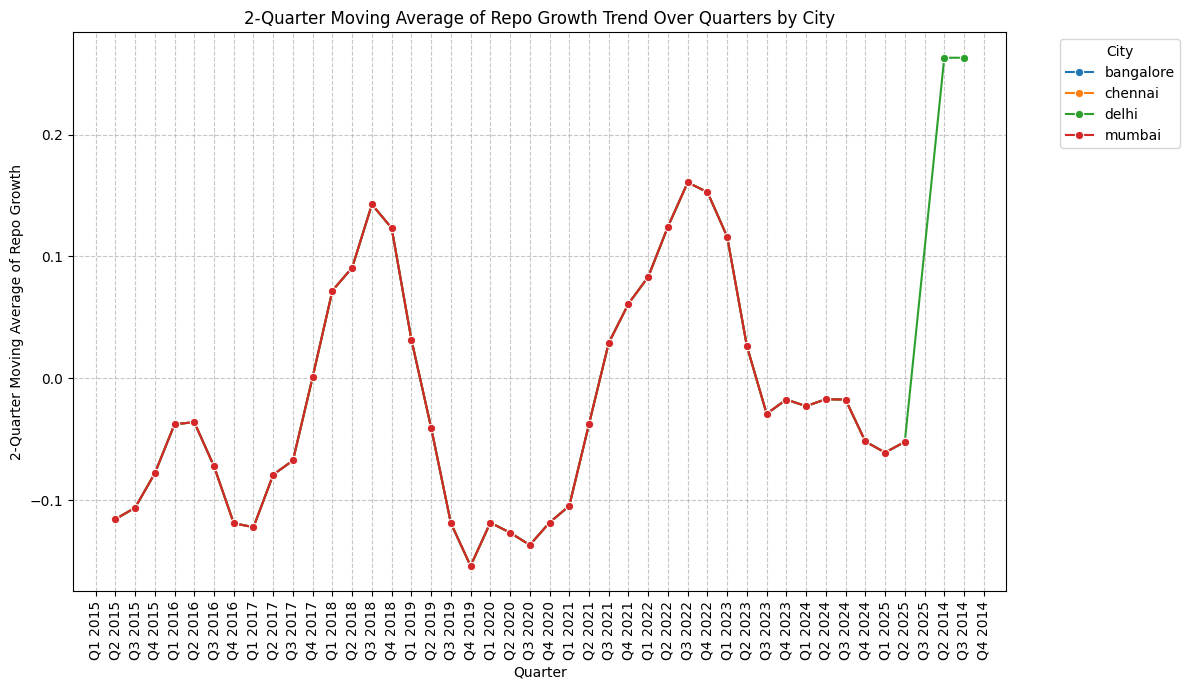

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='repo_growth_ma2', hue='city', data=df, marker='o')
plt.title('2-Quarter Moving Average of Repo Growth Trend Over Quarters by City')
plt.ylabel('2-Quarter Moving Average of Repo Growth')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

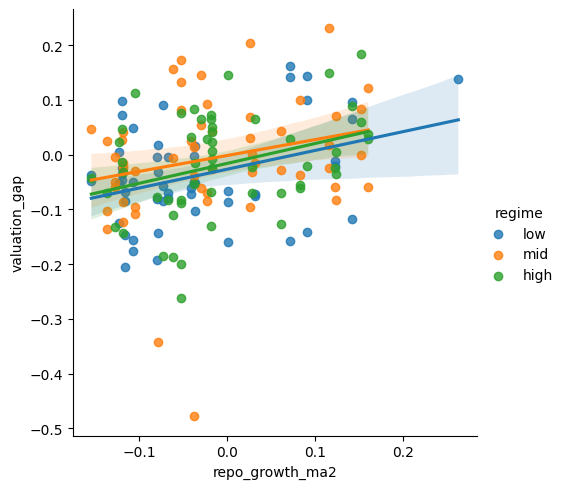

In [ ]:
sns.lmplot(
    data=df,
    x="repo_growth_ma2",
    y="valuation_gap",
    hue="regime"
)

In [ ]:
import pandas as pd

# Check if arch is installed, if not, install it.
try:
    import arch
except ImportError:
    print("The 'arch' library is not installed. Installing now...")
    !pip install arch
    import arch

# Extract the 'valuation_gap' series.
# GARCH models typically require a stationary series, often applied to residuals or returns.
# Modeling valuation_gap directly might require a mean model (e.g., Constant, AR(p))
# If valuation_gap itself is not stationary, the GARCH results might be misleading.
# For this request, we will directly model the series as requested.

valuation_gap_series = df['valuation_gap'].dropna()

if valuation_gap_series.empty:
    print("The 'valuation_gap' series is empty or contains only NaNs after dropping.")
elif len(valuation_gap_series) < 5: # GARCH usually needs more data points for reliable fitting
    print(f"Not enough data points ({len(valuation_gap_series)}) to fit a reliable GARCH model after dropping NaNs. Minimum 5-10 recommended.")
else:
    print(f"Fitting GARCH(1,1) model to 'valuation_gap' series with {len(valuation_gap_series)} data points.")
    # Fit a GARCH(1,1) model
    # 'vol' specifies the conditional variance model (GARCH)
    # 'p' is the order of the AR term in the variance model (ARCH)
    # 'q' is the order of the MA term in the variance model (GARCH)
    # 'mean' can be 'Constant', 'ARX', 'HARX', etc. For simplicity and direct interpretation, 'Constant' is a common start.
    model = arch.arch_model(valuation_gap_series, mean='Constant', vol='Garch', p=1, q=1, dist='normal')

    # Fit the model, 'disp='off'' suppresses optimization output
    try:
        results = model.fit(disp='off')
        print(results.summary())
        print("\nNote: GARCH models are typically applied to the residuals of a mean model (e.g., ARMA) "
              "or to asset returns, as the underlying series should ideally be stationary. "
              "If 'valuation_gap' is not stationary, consider differencing or fitting a mean model first.")
    except Exception as e:
        print(f"An error occurred during model fitting: {e}")

The 'arch' library is not installed. Installing now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 26.8 MB/s eta 0:00:00
Fitting GARCH(1,1) model to 'valuation_gap' series with 175 data points.
                     Constant Mean - GARCH Model Results                      
Dep. Variable:          valuation_gap   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                172.642
Distribution:                  Normal   AIC:                          -337.284
Method:            Maximum Likelihood   BIC:                          -324.625
                                        No. Observations:                  175
Date:                Fri, May 01 2026   Df Residuals:                      174
Time:                        15:16:50   Df Model:                            1
                                  Mean Model                                 
  

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01067. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


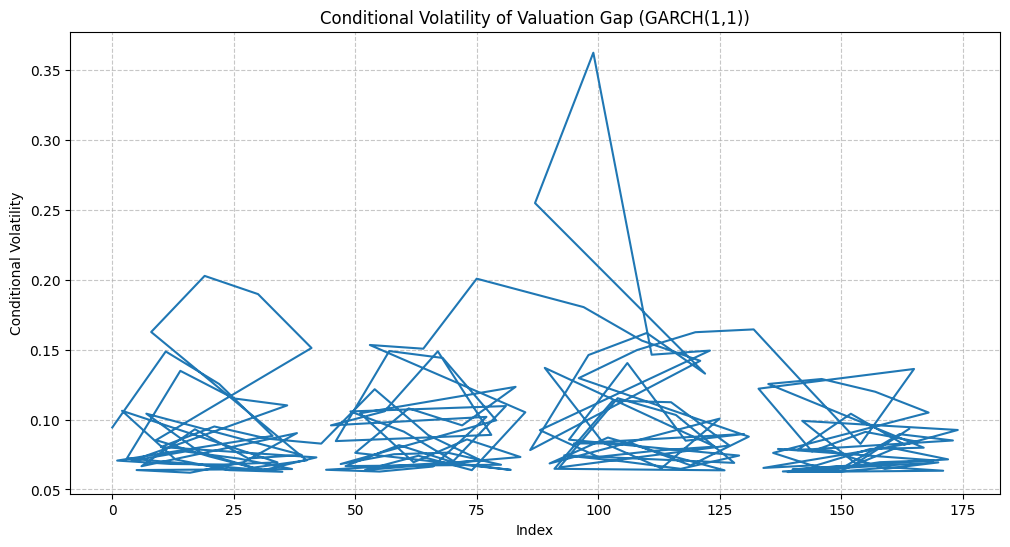

In [ ]:
if 'results' in locals():
    plt.figure(figsize=(12, 6))
    plt.plot(valuation_gap_series.index, results.conditional_volatility)
    plt.title('Conditional Volatility of Valuation Gap (GARCH(1,1))')
    plt.xlabel('Index')
    plt.ylabel('Conditional Volatility')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("GARCH model results not found. Please run the GARCH fitting cell first.")

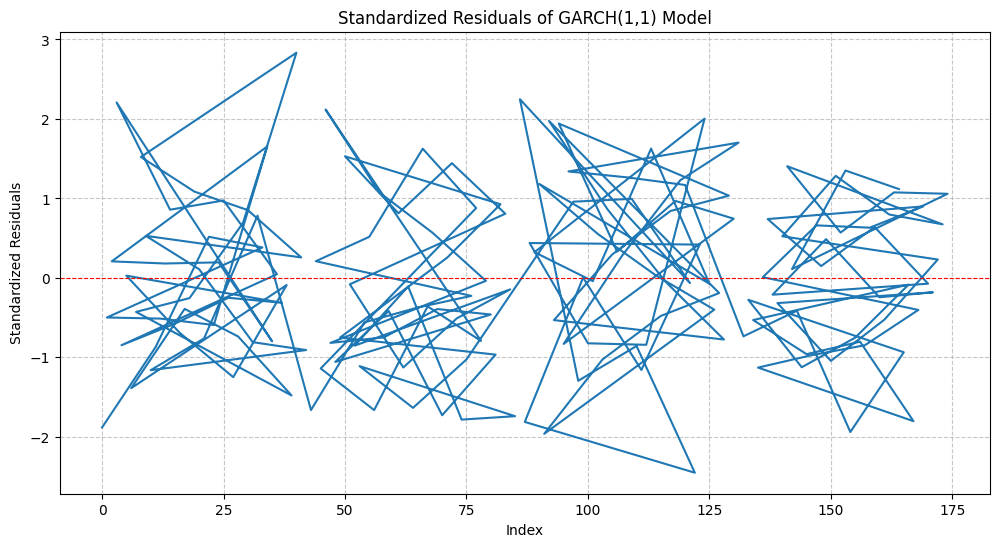

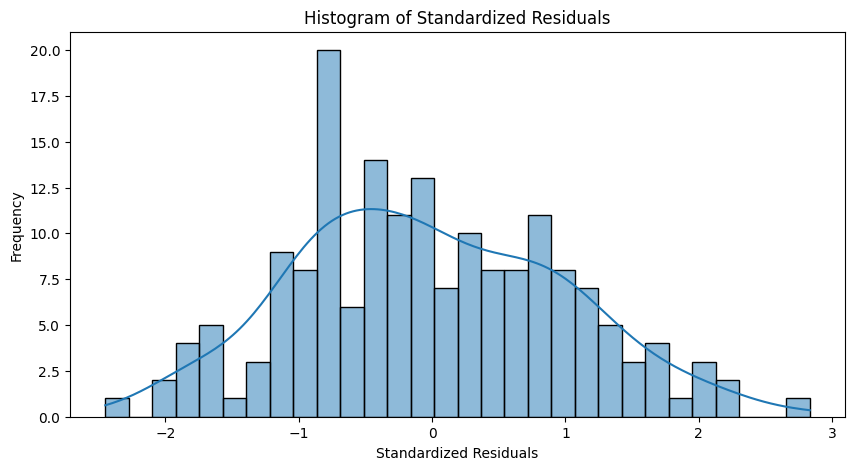

In [ ]:
if 'results' in locals():
    standardized_residuals = results.std_resid

    plt.figure(figsize=(12, 6))
    plt.plot(valuation_gap_series.index, standardized_residuals)
    plt.title('Standardized Residuals of GARCH(1,1) Model')
    plt.xlabel('Index')
    plt.ylabel('Standardized Residuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
    plt.show()

    # Also plot a histogram of residuals to check for normality
    plt.figure(figsize=(10, 5))
    sns.histplot(standardized_residuals, kde=True, bins=30)
    plt.title('Histogram of Standardized Residuals')
    plt.xlabel('Standardized Residuals')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("GARCH model results not found. Please run the GARCH fitting cell first.")

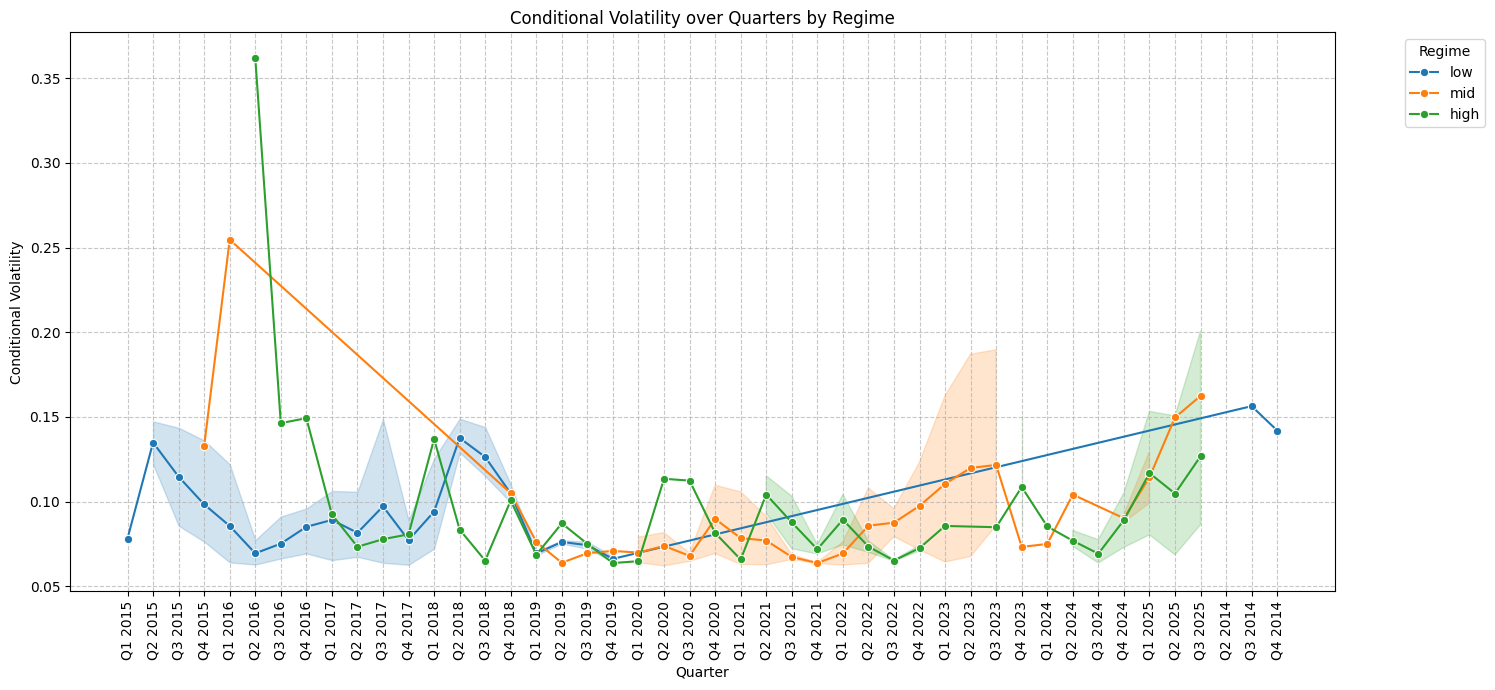

In [ ]:
if 'results' in locals() and 'df' in globals():
    # Get conditional volatility and align its index with original df
    conditional_volatility = results.conditional_volatility

    # Create a temporary DataFrame for plotting by joining conditional_volatility with relevant df columns
    # Ensure the index aligns
    plot_df = df.loc[conditional_volatility.index].copy()
    plot_df['conditional_volatility'] = conditional_volatility

    # The original df is already sorted by 'city' and 'year_quarter', so plot_df should maintain this order.
    # However, explicitly sorting again ensures chronological order if any prior operations disturbed it.
    plot_df = plot_df.sort_values(by=['city', 'year_quarter'])

    plt.figure(figsize=(15, 7))
    sns.lineplot(data=plot_df, x='quarter', y='conditional_volatility', hue='regime', marker='o')
    plt.title('Conditional Volatility over Quarters by Regime')
    plt.xlabel('Quarter')
    plt.ylabel('Conditional Volatility')
    plt.xticks(rotation=90)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Regime', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("GARCH model results or DataFrame not found. Please run the GARCH fitting cell and ensure 'df' is loaded.")

Build ARIMAX and GARCH


--- Modeling for city: Bangalore ---

Building ARIMAX(1,1,0) model for 'valuation_gap' of Bangalore with 'repo_growth_ma2' as exogenous variable.

ARIMAX Model Summary:
                               SARIMAX Results                                
Dep. Variable:          valuation_gap   No. Observations:                   41
Model:                 ARIMA(1, 1, 0)   Log Likelihood                  47.112
Date:                Fri, 01 May 2026   AIC                            -88.225
Time:                        18:06:02   BIC                            -83.158
Sample:                    04-01-2015   HQIC                           -86.393
                         - 04-01-2025                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
repo_growth_ma2     0.2095    

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.005787. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y

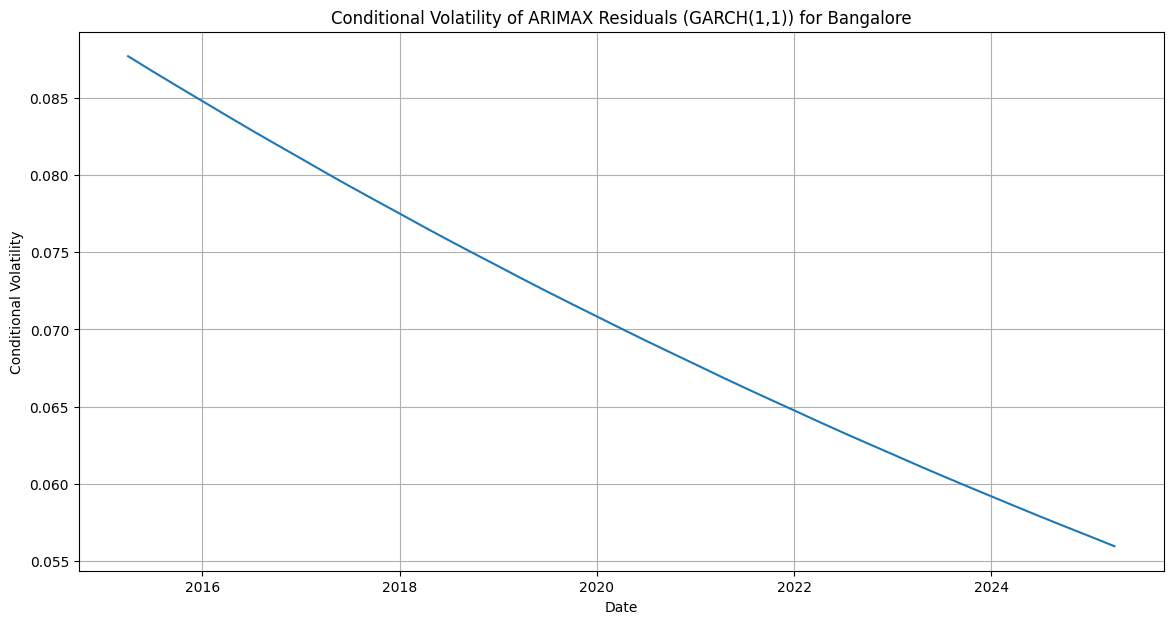


--- Model Estimates ---

ARIMAX Estimates for Bangalore:


,Coefficient,P-value,Conf. Int. Lower,Conf. Int. Upper
ARIMAX Parameter,,,,
repo_growth_ma2,0.209466,4.855303e-01,-0.379185,0.798118
ar.L1,-0.120025,5.844597e-01,-0.550181,0.310131
sigma2,0.005550,2.616928e-07,0.003438,0.007663


An error occurred during ARIMAX/GARCH fitting for Bangalore: 0
Please check the data and model order. You might need to adjust the ARIMAX order (p,d,q) or select a different exogenous variable.

--- Modeling for city: Chennai ---

Building ARIMAX(1,1,0) model for 'valuation_gap' of Chennai with 'repo_growth_ma2' as exogenous variable.

ARIMAX Model Summary:
                               SARIMAX Results                                
Dep. Variable:          valuation_gap   No. Observations:                   41
Model:                 ARIMA(1, 1, 0)   Log Likelihood                  49.266
Date:                Fri, 01 May 2026   AIC                            -92.532
Time:                        18:06:02   BIC                            -87.465
Sample:                    04-01-2015   HQIC                           -90.700
                         - 04-01-2025                                         
Covariance Type:                  opg                                         
        

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.004843. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y

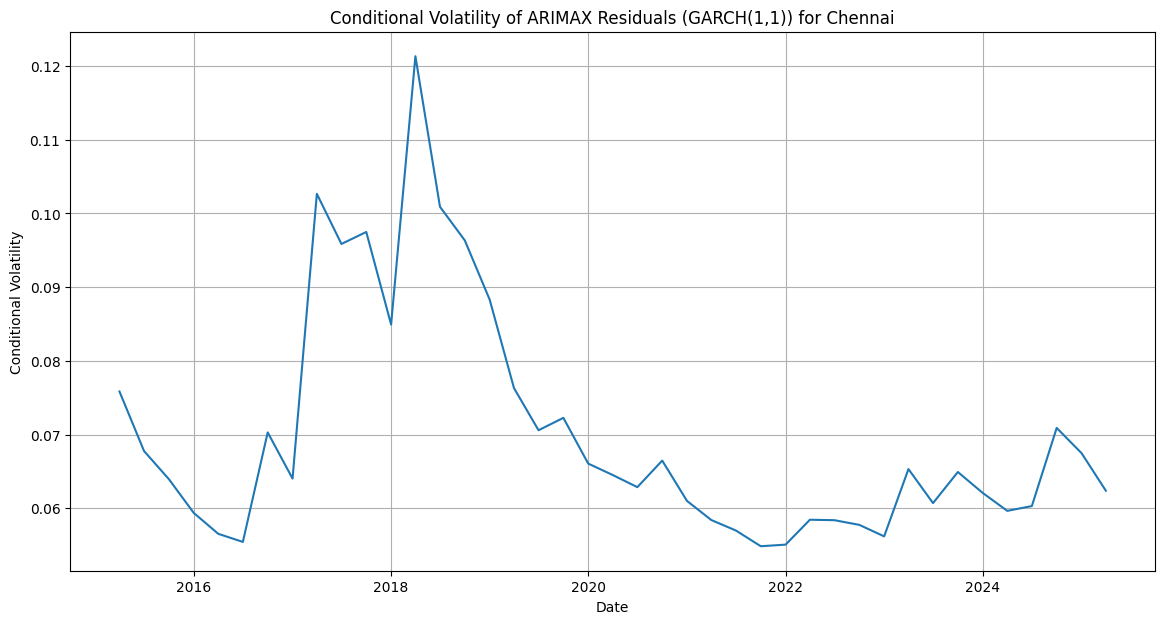


--- Model Estimates ---

ARIMAX Estimates for Chennai:


,Coefficient,P-value,Conf. Int. Lower,Conf. Int. Upper
ARIMAX Parameter,,,,
repo_growth_ma2,0.528100,8.071979e-02,-0.064538,1.120738
ar.L1,-0.047956,7.971182e-01,-0.413574,0.317662
sigma2,0.004985,7.058697e-07,0.003015,0.006955


An error occurred during ARIMAX/GARCH fitting for Chennai: 0
Please check the data and model order. You might need to adjust the ARIMAX order (p,d,q) or select a different exogenous variable.

--- Modeling for city: Delhi ---

Building ARIMAX(1,1,0) model for 'valuation_gap' of Delhi with 'repo_growth_ma2' as exogenous variable.

ARIMAX Model Summary:
                               SARIMAX Results                                
Dep. Variable:          valuation_gap   No. Observations:                   43
Model:                 ARIMA(1, 1, 0)   Log Likelihood                  30.668
Date:                Fri, 01 May 2026   AIC                            -55.337
Time:                        18:06:03   BIC                            -50.124
Sample:                             0   HQIC                           -53.426
                                 - 43                                         
Covariance Type:                  opg                                         
              

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01323. Parameter
estimation work better

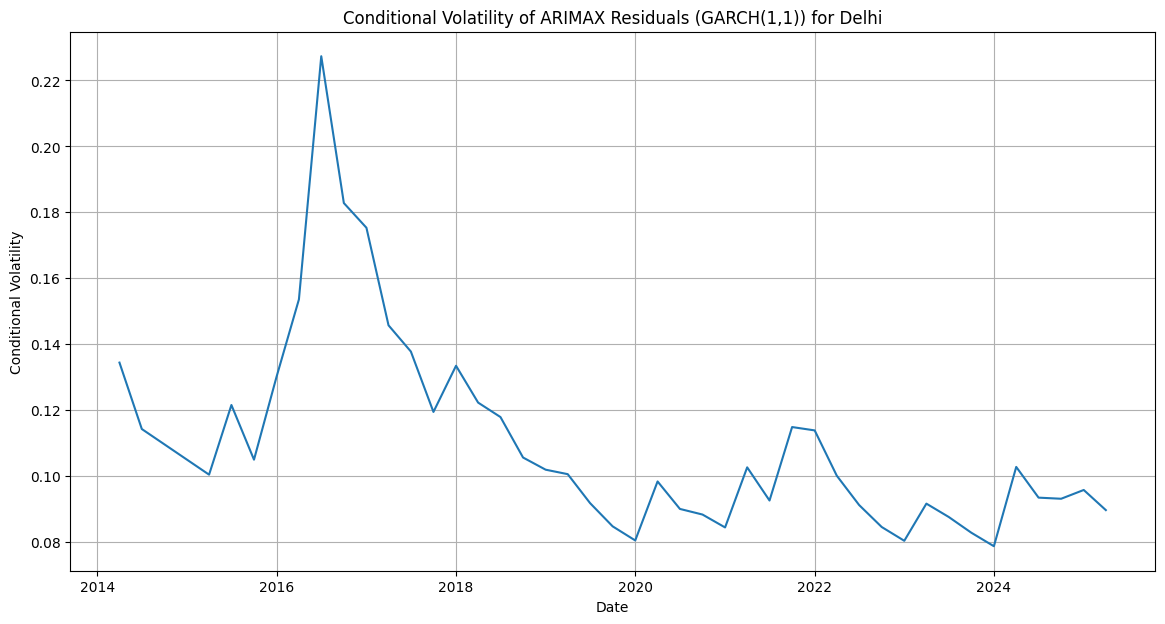


--- Model Estimates ---

ARIMAX Estimates for Delhi:


,Coefficient,P-value,Conf. Int. Lower,Conf. Int. Upper
ARIMAX Parameter,,,,
repo_growth_ma2,0.486176,1.129035e-02,0.110073,0.862279
ar.L1,-0.317420,7.446923e-02,-0.666203,0.031363
sigma2,0.013557,1.114289e-07,0.008550,0.018563


An error occurred during ARIMAX/GARCH fitting for Delhi: 0
Please check the data and model order. You might need to adjust the ARIMAX order (p,d,q) or select a different exogenous variable.

--- Modeling for city: Mumbai ---

Building ARIMAX(1,1,0) model for 'valuation_gap' of Mumbai with 'repo_growth_ma2' as exogenous variable.

ARIMAX Model Summary:
                               SARIMAX Results                                
Dep. Variable:          valuation_gap   No. Observations:                   41
Model:                 ARIMA(1, 1, 0)   Log Likelihood                  69.577
Date:                Fri, 01 May 2026   AIC                           -133.153
Time:                        18:06:03   BIC                           -128.087
Sample:                    04-01-2015   HQIC                          -131.321
                         - 04-01-2025                                         
Covariance Type:                  opg                                         
              

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002034. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y

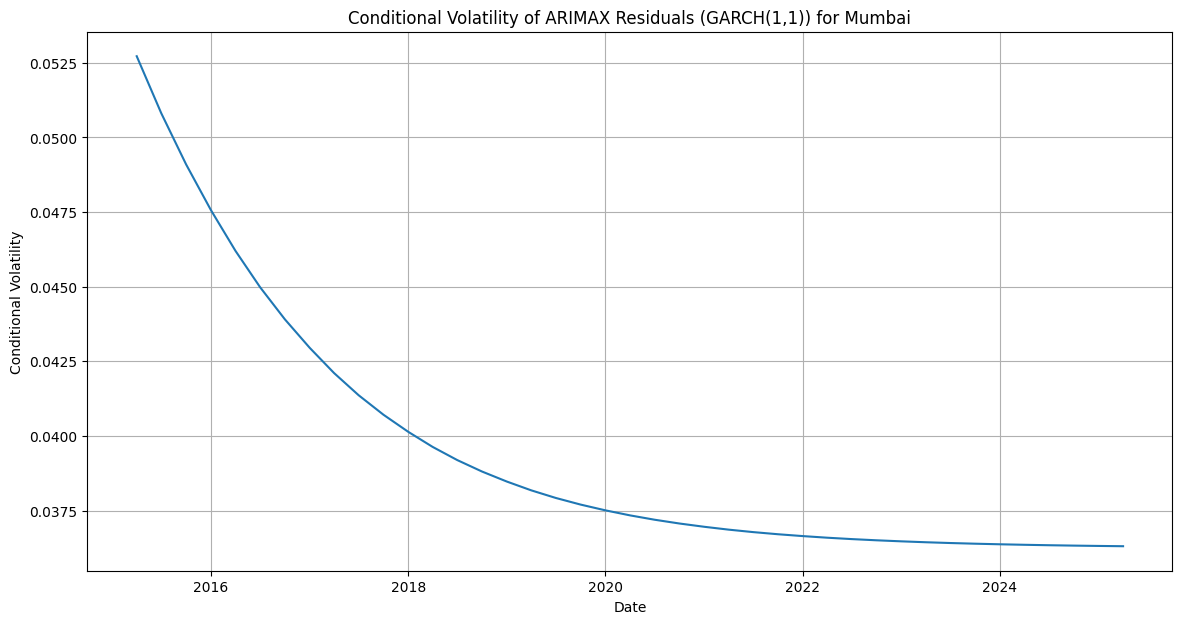


--- Model Estimates ---

ARIMAX Estimates for Mumbai:


,Coefficient,P-value,Conf. Int. Lower,Conf. Int. Upper
ARIMAX Parameter,,,,
repo_growth_ma2,-0.297193,0.080956,-0.630965,0.036579
ar.L1,-0.323591,0.103422,-0.713049,0.065867
sigma2,0.001801,0.000003,0.001042,0.002560


An error occurred during ARIMAX/GARCH fitting for Mumbai: 0
Please check the data and model order. You might need to adjust the ARIMAX order (p,d,q) or select a different exogenous variable.


In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded
df = pd.read_csv('/content/final_model_dataset.csv')

# Ensure 'year_quarter' and 'repo_growth_ma2' are in df, as they are created in previous cells.
# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Re-create 'repo_growth_ma2' if not already present
if 'repo_growth_ma2' not in df.columns:
    df['repo_growth_ma2'] = df.groupby('city')['repo_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

# List of cities to process
cities_to_process = ['bangalore', 'chennai', 'delhi', 'mumbai'] # User specified cities

for city_name in cities_to_process:
    print(f"\n--- Modeling for city: {city_name.capitalize()} ---")
    df_city = df[df['city'] == city_name].copy()

    # Convert 'quarter' to a proper datetime index for time series analysis
    df_city['quarter_dt'] = pd.PeriodIndex(df_city['quarter'].str.replace(r'Q(\d) (\d{4})', r'\2-Q\1', regex=True), freq='Q').to_timestamp()
    df_city = df_city.set_index('quarter_dt').sort_index()

    # Define endogenous (dependent) and exogenous variables
    endog = df_city['valuation_gap'].dropna()
    exog = df_city['repo_growth_ma2'].loc[endog.index].dropna() # Align exog with endog index

    # Ensure endog and exog have the same length and index after dropping NaNs
    common_index = endog.index.intersection(exog.index)
    endog = endog.loc[common_index]
    exog = exog.loc[common_index]

    # --- ARIMAX Model Building ---
    if endog.empty or exog.empty or len(endog) < 10: # Minimum 10 data points recommended for time series
        print(f"Not enough data (current: {len(endog)} points) for ARIMAX model for city: {city_name.capitalize()} after handling NaNs. Skipping ARIMAX/GARCH for this city.")
    elif len(exog) == 0:
        print(f"Exogenous variable 'repo_growth_ma2' is empty for city: {city_name.capitalize()}. Skipping ARIMAX/GARCH.")
    else:
        print(f"\nBuilding ARIMAX(1,1,0) model for 'valuation_gap' of {city_name.capitalize()} with 'repo_growth_ma2' as exogenous variable.")
        try:
            # Fit ARIMAX model (ARIMA with exogenous variables)
            # order=(p,d,q). (1,1,0) means 1 AR term, 1 differencing, 0 MA terms.
            arimax_model = ARIMA(endog, exog=exog, order=(1,1,0))
            arimax_results = arimax_model.fit()
            print("\nARIMAX Model Summary:")
            print(arimax_results.summary())

            # Extract residuals from ARIMAX model for GARCH modeling
            arimax_residuals = arimax_results.resid.dropna()

            # --- GARCH Model Building on ARIMAX Residuals ---
            if len(arimax_residuals) < 10: # GARCH usually needs more data points for reliable fitting
                print(f"Not enough ARIMAX residuals ({len(arimax_residuals)}) to fit a reliable GARCH model. Skipping GARCH.")
            else:
                print(f"\nFitting GARCH(1,1) model to ARIMAX residuals for {city_name.capitalize()} with {len(arimax_residuals)} data points.")
                # Fit GARCH(1,1) model to ARIMAX residuals
                # 'mean='Constant'' is often used for residuals as they should ideally have a zero mean.
                garch_model_on_residuals = arch_model(arimax_residuals, mean='Constant', vol='Garch', p=1, q=1, dist='normal')

                # Suppress optimization output for cleaner display
                garch_results_on_residuals = garch_model_on_residuals.fit(disp='off')
                print("\nGARCH Model on ARIMAX Residuals Summary:")
                print(garch_results_on_residuals.summary())

                # --- Plot Conditional Volatility of ARIMAX Residuals ---
                plt.figure(figsize=(14, 7))
                plt.plot(garch_results_on_residuals.conditional_volatility.index, garch_results_on_residuals.conditional_volatility)
                plt.title(f'Conditional Volatility of ARIMAX Residuals (GARCH(1,1)) for {city_name.capitalize()}')
                plt.xlabel('Date')
                plt.ylabel('Conditional Volatility')
                plt.grid(True)
                plt.show()

                # --- Table the Estimates ---
                print("\n--- Model Estimates ---")

                # ARIMAX estimates
                arimax_params = arimax_results.params
                arimax_pvalues = arimax_results.pvalues
                arimax_conf_int = arimax_results.conf_int()
                arimax_estimates_df = pd.DataFrame({
                    'Coefficient': arimax_params,
                    'P-value': arimax_pvalues,
                    'Conf. Int. Lower': arimax_conf_int[0],
                    'Conf. Int. Upper': arimax_conf_int[1]
                })
                arimax_estimates_df.index.name = 'ARIMAX Parameter'
                print(f"\nARIMAX Estimates for {city_name.capitalize()}:")
                display(arimax_estimates_df)

                # GARCH estimates
                garch_params = garch_results_on_residuals.params
                garch_pvalues = garch_results_on_residuals.pvalues
                garch_conf_int = garch_results_on_residuals.conf_int()
                garch_estimates_df = pd.DataFrame({
                    'Coefficient': garch_params,
                    'P-value': garch_pvalues,
                    'Conf. Int. Lower': garch_conf_int[0],
                    'Conf. Int. Upper': garch_conf_int[1]
                })
                garch_estimates_df.index.name = 'GARCH Parameter'
                print(f"\nGARCH Estimates on ARIMAX Residuals for {city_name.capitalize()}:")
                display(garch_estimates_df)

        except Exception as e:
            print(f"An error occurred during ARIMAX/GARCH fitting for {city_name.capitalize()}: {e}")
            print("Please check the data and model order. You might need to adjust the ARIMAX order (p,d,q) or select a different exogenous variable.")

In [7]:
from statsmodels.tsa.stattools import adfuller

print("--- Performing ADF test for each city's valuation_gap ---")

cities_to_process = df['city'].unique()

for city_name in cities_to_process:
    df_city = df[df['city'] == city_name].copy()
    valuation_gap_series = df_city['valuation_gap'].dropna()

    if len(valuation_gap_series) > 0:
        print(f"\nADF Test for {city_name.capitalize()}:")
        try:
            adf_result = adfuller(valuation_gap_series)
            print('ADF Statistic: %f' % adf_result[0])
            print('p-value: %f' % adf_result[1])
            print('Critical Values:')
            for key, value in adf_result[4].items():
                print('\t%s: %.3f' % (key, value))

            if adf_result[1] <= 0.05:
                print(f"Conclusion for {city_name.capitalize()}: The p-value is less than or equal to 0.05. We reject the null hypothesis, meaning the series is likely stationary.")
            else:
                print(f"Conclusion for {city_name.capitalize()}: The p-value is greater than 0.05. We fail to reject the null hypothesis, meaning the series is likely non-stationary.")
        except Exception as e:
            print(f"Error performing ADF test for {city_name.capitalize()}: {e}")
    else:
        print(f"\nNo data to perform ADF test for {city_name.capitalize()}'s valuation_gap.")

--- Performing ADF test for each city's valuation_gap ---

ADF Test for Bangalore:
ADF Statistic: -1.907456
p-value: 0.328562
Critical Values:
	1%: -3.639
	5%: -2.951
	10%: -2.614
Conclusion for Bangalore: The p-value is greater than 0.05. We fail to reject the null hypothesis, meaning the series is likely non-stationary.

ADF Test for Chennai:
ADF Statistic: -1.424072
p-value: 0.570683
Critical Values:
	1%: -3.633
	5%: -2.949
	10%: -2.613
Conclusion for Chennai: The p-value is greater than 0.05. We fail to reject the null hypothesis, meaning the series is likely non-stationary.

ADF Test for Delhi:
ADF Statistic: -3.811212
p-value: 0.002795
Critical Values:
	1%: -3.585
	5%: -2.928
	10%: -2.602
Conclusion for Delhi: The p-value is less than or equal to 0.05. We reject the null hypothesis, meaning the series is likely stationary.

ADF Test for Mumbai:
ADF Statistic: -1.124930
p-value: 0.705029
Critical Values:
	1%: -3.616
	5%: -2.941
	10%: -2.609
Conclusion for Mumbai: The p-value is gr

Overall ARIMAX-GARCH


--- Modeling Overall ARIMAX GARCH for valuation_gap ---
Number of observations for overall model: 43

Building Overall ARIMAX(1,1,0) model for aggregated 'valuation_gap' with aggregated 'repo_growth_ma2' as exogenous variable.

Overall ARIMAX Model Summary:
                               SARIMAX Results                                
Dep. Variable:          valuation_gap   No. Observations:                   43
Model:                 ARIMA(1, 1, 0)   Log Likelihood                  71.429
Date:                Fri, 01 May 2026   AIC                           -136.859
Time:                        18:13:50   BIC                           -131.646
Sample:                             0   HQIC                          -134.948
                                 - 43                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00193. Parameter
estimation work better

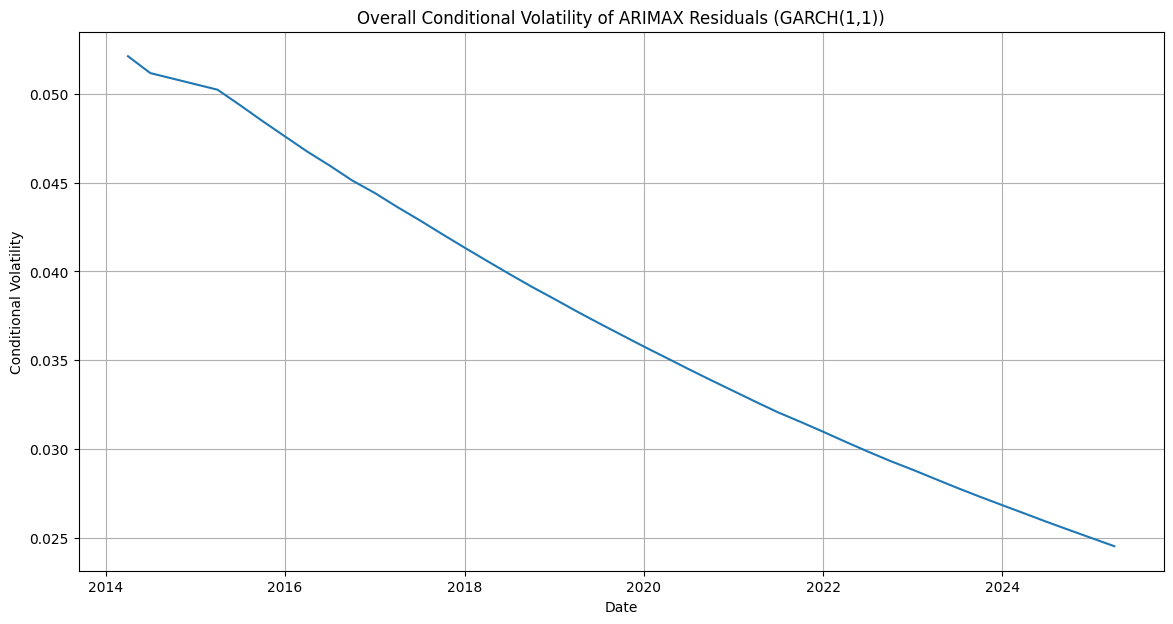


--- Overall Model Estimates ---

Overall ARIMAX Estimates:


,Coefficient,P-value,Conf. Int. Lower,Conf. Int. Upper
ARIMAX Parameter,,,,
repo_growth_ma2,0.469738,5.408262e-18,0.363233,0.576243
ar.L1,-0.135217,3.400299e-01,-0.412984,0.142551
sigma2,0.001950,1.449602e-07,0.001223,0.002677


An error occurred during Overall ARIMAX/GARCH fitting: 0
Please check the data and model order. You might need to adjust the ARIMAX order (p,d,q) or select a different exogenous variable.


In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and necessary columns are prepared
# (Assuming df is already loaded and in scope from previous cells, but adding safeguards)
if 'df' not in locals() or df.empty:
    df = pd.read_csv('/content/final_model_dataset.csv')

# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Re-create 'repo_growth_ma2' if not already present
if 'repo_growth_ma2' not in df.columns:
    df['repo_growth_ma2'] = df.groupby('city')['repo_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

# --- Prepare data for Overall ARIMAX GARCH ---
# Convert 'quarter' to a proper datetime index for time series analysis
df['quarter_dt'] = pd.PeriodIndex(df['quarter'].str.replace(r'Q(\d) (\d{4})', r'\2-Q\1', regex=True), freq='Q').to_timestamp()

# Aggregate valuation_gap and repo_growth_ma2 across cities for each quarter
# Taking the mean as a reasonable aggregation for an 'overall' series
df_overall = df.groupby('quarter_dt')[['valuation_gap', 'repo_growth_ma2']].mean().dropna()

# Define endogenous (dependent) and exogenous variables for the overall model
endog_overall = df_overall['valuation_gap']
exog_overall = df_overall['repo_growth_ma2']

print(f"\n--- Modeling Overall ARIMAX GARCH for valuation_gap ---")
print(f"Number of observations for overall model: {len(endog_overall)}")

# --- ARIMAX Model Building ---
if endog_overall.empty or exog_overall.empty or len(endog_overall) < 10: # Minimum 10 data points recommended for time series
    print(f"Not enough data ({len(endog_overall)} points) for Overall ARIMAX model after aggregation and handling NaNs. Skipping ARIMAX/GARCH.")
else:
    print(f"\nBuilding Overall ARIMAX(1,1,0) model for aggregated 'valuation_gap' with aggregated 'repo_growth_ma2' as exogenous variable.")
    try:
        # Fit ARIMAX model (ARIMA with exogenous variables)
        # order=(p,d,q). (1,1,0) means 1 AR term, 1 differencing, 0 MA terms.
        overall_arimax_model = ARIMA(endog_overall, exog=exog_overall, order=(1,1,0))
        overall_arimax_results = overall_arimax_model.fit()
        print("\nOverall ARIMAX Model Summary:")
        print(overall_arimax_results.summary())

        # Extract residuals from ARIMAX model for GARCH modeling
        overall_arimax_residuals = overall_arimax_results.resid.dropna()

        # --- GARCH Model Building on ARIMAX Residuals ---
        if len(overall_arimax_residuals) < 10: # GARCH usually needs more data points for reliable fitting
            print(f"Not enough ARIMAX residuals ({len(overall_arimax_residuals)}) to fit a reliable GARCH model. Skipping GARCH.")
        else:
            print(f"\nFitting Overall GARCH(1,1) model to ARIMAX residuals with {len(overall_arimax_residuals)} data points.")
            # Fit GARCH(1,1) model to ARIMAX residuals
            # 'mean='Constant'' is often used for residuals as they should ideally have a zero mean.
            overall_garch_model_on_residuals = arch_model(overall_arimax_residuals, mean='Constant', vol='Garch', p=1, q=1, dist='normal')

            # Suppress optimization output for cleaner display
            overall_garch_results_on_residuals = overall_garch_model_on_residuals.fit(disp='off')
            print("\nOverall GARCH Model on ARIMAX Residuals Summary:")
            print(overall_garch_results_on_residuals.summary())

            # --- Plot Conditional Volatility of ARIMAX Residuals ---
            plt.figure(figsize=(14, 7))
            plt.plot(overall_garch_results_on_residuals.conditional_volatility.index, overall_garch_results_on_residuals.conditional_volatility)
            plt.title('Overall Conditional Volatility of ARIMAX Residuals (GARCH(1,1))')
            plt.xlabel('Date')
            plt.ylabel('Conditional Volatility')
            plt.grid(True)
            plt.show()

            # --- Table the Estimates ---
            print("\n--- Overall Model Estimates ---")

            # ARIMAX estimates
            overall_arimax_params = overall_arimax_results.params
            overall_arimax_pvalues = overall_arimax_results.pvalues
            overall_arimax_conf_int = overall_arimax_results.conf_int()
            overall_arimax_estimates_df = pd.DataFrame({
                'Coefficient': overall_arimax_params,
                'P-value': overall_arimax_pvalues,
                'Conf. Int. Lower': overall_arimax_conf_int[0],
                'Conf. Int. Upper': overall_arimax_conf_int[1]
            })
            overall_arimax_estimates_df.index.name = 'ARIMAX Parameter'
            print("\nOverall ARIMAX Estimates:")
            display(overall_arimax_estimates_df)

            # GARCH estimates
            overall_garch_params = overall_garch_results_on_residuals.params
            overall_garch_pvalues = overall_garch_results_on_residuals.pvalues
            overall_garch_conf_int = overall_garch_results_on_residuals.conf_int()
            overall_garch_estimates_df = pd.DataFrame({
                'Coefficient': overall_garch_params,
                'P-value': overall_garch_pvalues,
                'Conf. Int. Lower': overall_garch_conf_int[0],
                'Conf. Int. Upper': overall_garch_conf_int[1]
            })
            overall_garch_estimates_df.index.name = 'GARCH Parameter'
            print("\nOverall GARCH Estimates on ARIMAX Residuals:")
            display(overall_garch_estimates_df)

    except Exception as e:
        print(f"An error occurred during Overall ARIMAX/GARCH fitting: {e}")
        print("Please check the data and model order. You might need to adjust the ARIMAX order (p,d,q) or select a different exogenous variable.")